In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/processed/reddit_posts_cleaned.csv")

df.head()

,keyword,title,subreddit,timestamp,post_url,clean_title,location,skill,role
0,developersindia hiring,How's Infosys for starters 😳,r/IndiaTech,2026-03-10T07:42:32+00:00,https://old.reddit.com/r/IndiaTech/comments/1r...,hows infosys for starters,Unknown,Unknown,Unknown
1,developersindia hiring,Who's hiring? - Monthly Megathread - June 2026,r/developersIndia,2026-06-01T04:32:05+00:00,https://old.reddit.com/r/developersIndia/comme...,whos hiring monthly megathread june 2026,Unknown,Unknown,Unknown
2,developersindia hiring,Who's hiring? - Monthly Megathread - February ...,r/developersIndia,2026-02-01T04:32:29+00:00,https://old.reddit.com/r/developersIndia/comme...,whos hiring monthly megathread february 2026,Unknown,Unknown,Unknown
3,developersindia hiring,Who's looking for work? - Monthly Megathread -...,r/developersIndia,2026-06-01T04:30:14+00:00,https://old.reddit.com/r/developersIndia/comme...,whos looking for work monthly megathread june ...,Unknown,Unknown,Unknown
4,developersindia hiring,Who's hiring? - Monthly Megathread - May 2026,r/developersIndia,2026-05-01T04:32:13+00:00,https://old.reddit.com/r/developersIndia/comme...,whos hiring monthly megathread may 2026,Unknown,Unknown,Unknown


# Part 1 – Top Subreddits

In [3]:
subreddit_counts = df["subreddit"].value_counts().head(10)

subreddit_counts

subreddit
r/developersIndia        63
r/resumes                 6
r/leetcode                4
r/IndiaCareers            4
r/DataAnalystsIndia       4
r/hyderabad               4
r/india                   4
r/DataAnalytics_India     4
r/Btechtards              3
r/csMajors                3
Name: count, dtype: int64

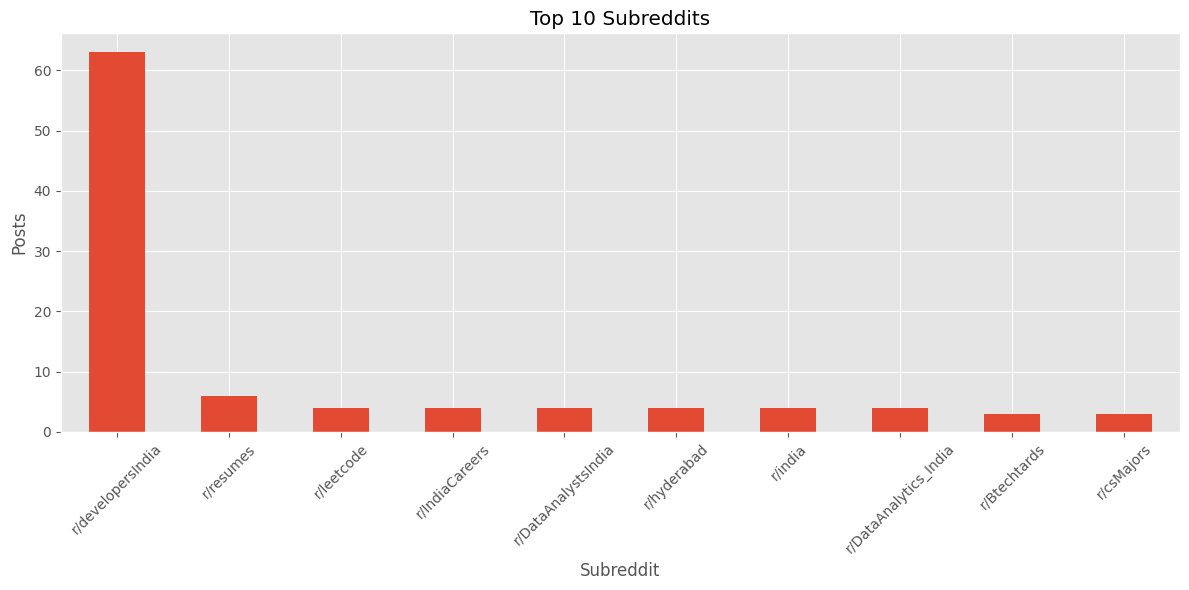

In [4]:
plt.figure(figsize=(12,6))

subreddit_counts.plot(
    kind="bar"
)

plt.title("Top 10 Subreddits")

plt.xlabel("Subreddit")

plt.ylabel("Posts")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../reports/figures/top_subreddits.png")

plt.show()

# Part 2 – Role Distribution

In [5]:
role_counts = (
    df["role"]
    .value_counts()
    .drop("Unknown", errors="ignore")
)

role_counts

role
Software Engineer                24
Data Analyst                     16
Machine Learning Engineer         9
AI Engineer                       2
Intern                            2
Software Development Engineer     1
Backend Developer                 1
Name: count, dtype: int64

plt.figure(figsize=(8,6))

role_counts.plot(
    kind="bar"
)

plt.title("Job Roles")

plt.xlabel("Role")

plt.ylabel("Count")

plt.tight_layout()

plt.savefig("../reports/figures/dashboard_roles.png")

plt.show()

# Part 3 – Skill Distribution

In [7]:
skill_counts = (
    df["skill"]
    .value_counts()
    .drop("Unknown", errors="ignore")
)

skill_counts

skill
Artificial Intelligence    41
Git                         1
Python                      1
Machine Learning            1
Name: count, dtype: int64

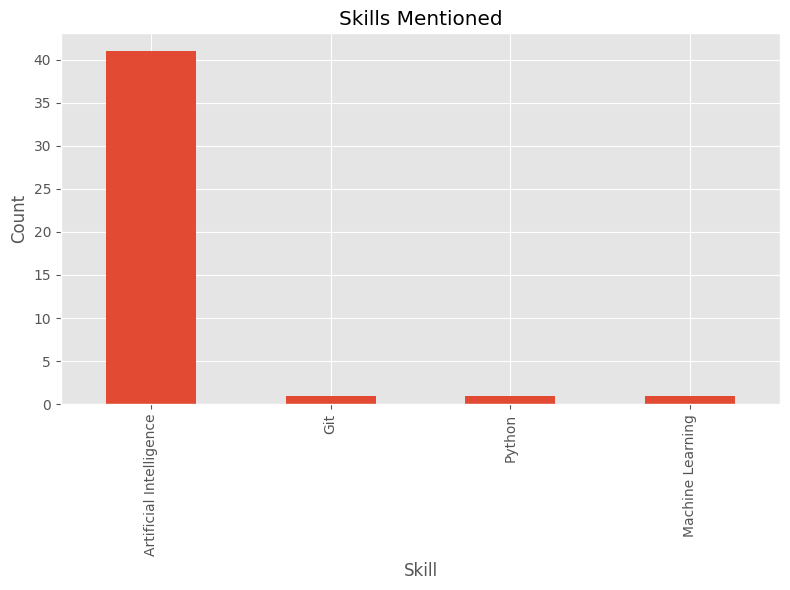

In [8]:
plt.figure(figsize=(8,6))

skill_counts.plot(
    kind="bar"
)

plt.title("Skills Mentioned")

plt.xlabel("Skill")

plt.ylabel("Count")

plt.tight_layout()

plt.savefig("../reports/figures/dashboard_skills.png")

plt.show()

# Part 4 – Location Distribution

In [9]:
location_counts = (
    df["location"]
    .value_counts()
    .drop("Unknown", errors="ignore")
)

location_counts

location
Bangalore    13
Hyderabad     5
Delhi         2
Mumbai        1
Name: count, dtype: int64

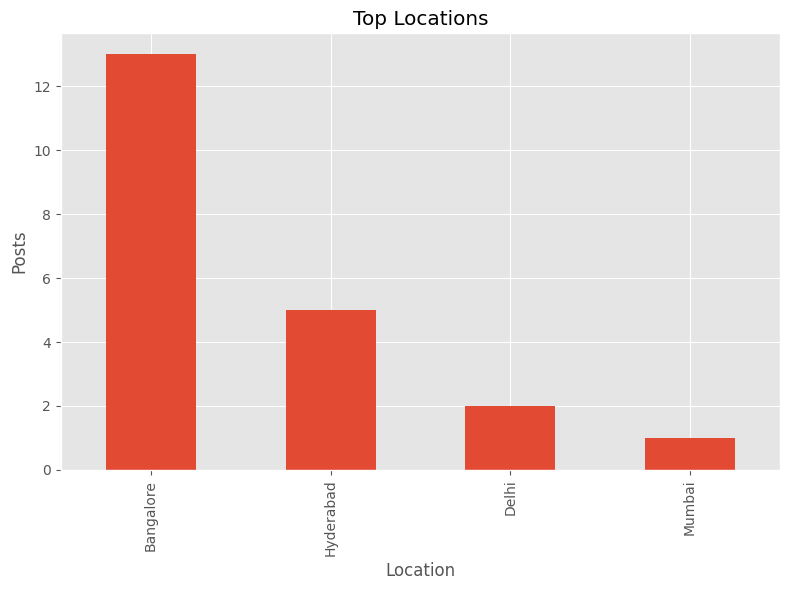

In [10]:
plt.figure(figsize=(8,6))

location_counts.plot(
    kind="bar"
)

plt.title("Top Locations")

plt.xlabel("Location")

plt.ylabel("Posts")

plt.tight_layout()

plt.savefig("../reports/figures/dashboard_locations.png")

plt.show()

# Part 5 – Role vs Location (Cross Analysis)

In [11]:
cross = pd.crosstab(
    df["role"],
    df["location"]
)

cross

location,Bangalore,Delhi,Hyderabad,Mumbai,Unknown
role,,,,,
AI Engineer,0,0,0,0,2
Backend Developer,0,0,1,0,0
Data Analyst,0,1,1,0,14
Intern,0,0,0,0,2
Machine Learning Engineer,0,0,0,0,9
Software Development Engineer,0,0,0,0,1
Software Engineer,11,0,0,0,13
Unknown,2,1,3,1,114


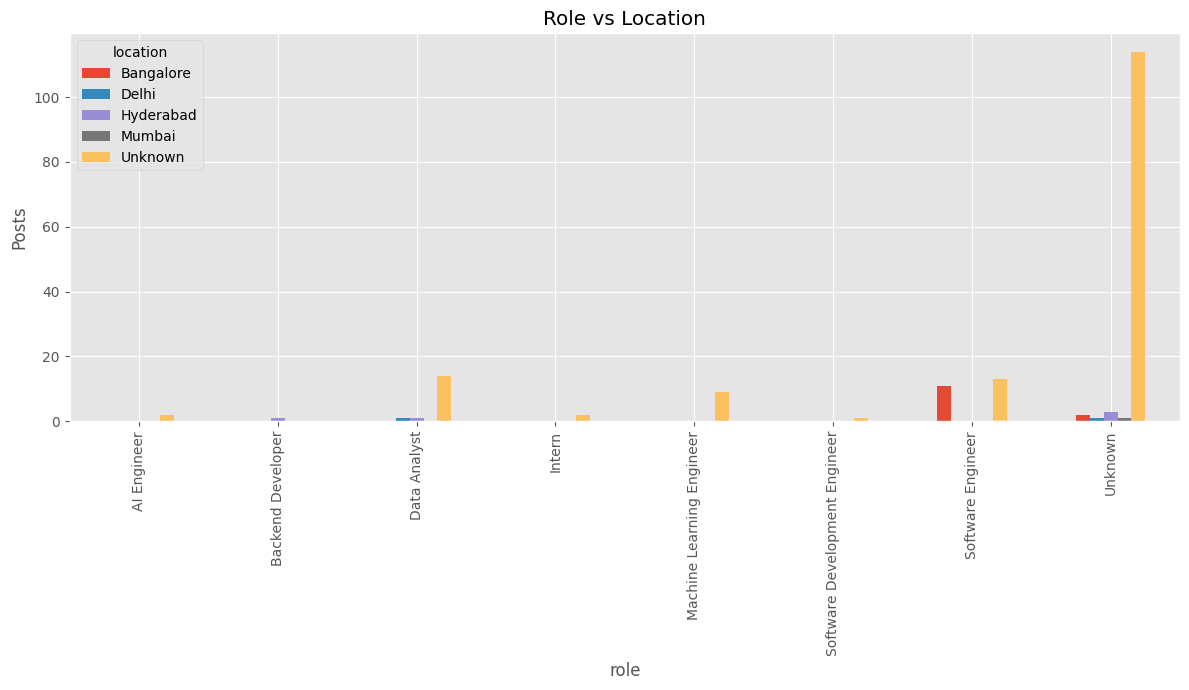

In [12]:
cross.plot(
    kind="bar",
    figsize=(12,7)
)

plt.title("Role vs Location")

plt.ylabel("Posts")

plt.tight_layout()

plt.savefig("../reports/figures/role_location.png")

plt.show()

# Part 6 – Skill vs Role

In [13]:
cross2 = pd.crosstab(
    df["skill"],
    df["role"]
)

cross2

role,AI Engineer,Backend Developer,Data Analyst,Intern,Machine Learning Engineer,Software Development Engineer,Software Engineer,Unknown
skill,,,,,,,,
Artificial Intelligence,2,1,1,0,3,0,2,32
Git,0,0,0,0,0,0,1,0
Machine Learning,0,0,0,0,1,0,0,0
Python,0,0,0,0,0,0,1,0
Unknown,0,0,15,2,5,1,20,89


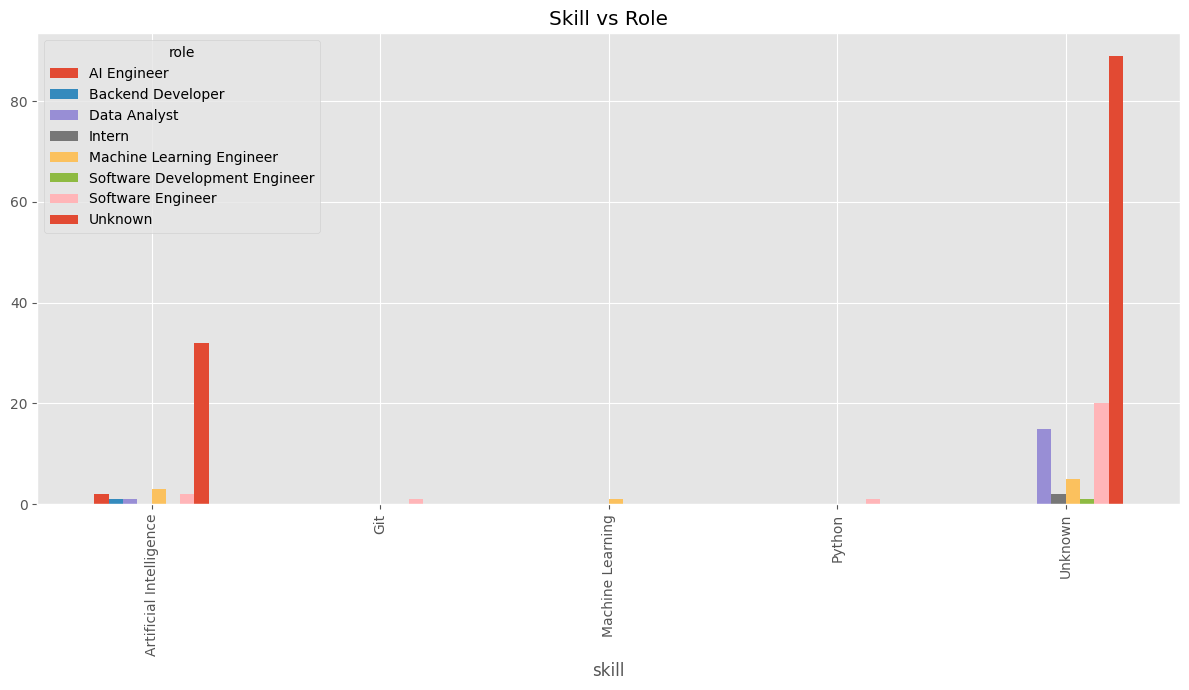

In [14]:
cross2.plot(
    kind="bar",
    figsize=(12,7)
)

plt.title("Skill vs Role")

plt.tight_layout()

plt.savefig("../reports/figures/skill_role.png")

plt.show()

# Part 7 – Dataset Statistics

In [15]:
print("Total Posts :", len(df))
print("Unique Roles :", df["role"].nunique())
print("Unique Skills :", df["skill"].nunique())
print("Unique Locations :", df["location"].nunique())
print("Unique Subreddits :", df["subreddit"].nunique())

Total Posts : 176
Unique Roles : 8
Unique Skills : 5
Unique Locations : 5
Unique Subreddits : 73


In [16]:
summary = pd.DataFrame({

    "Metric":[
        "Posts",
        "Roles",
        "Skills",
        "Locations",
        "Subreddits"
    ],

    "Value":[
        len(df),
        df["role"].nunique(),
        df["skill"].nunique(),
        df["location"].nunique(),
        df["subreddit"].nunique()
    ]

})

summary

,Metric,Value
0,Posts,176
1,Roles,8
2,Skills,5
3,Locations,5
4,Subreddits,73


In [17]:
summary.to_csv(
    "../reports/dashboard_summary.csv",
    index=False
)

# Dashboard Insights

## Observations

- Most employment discussions occur in r/developersIndia.
- Software Engineer is the most frequently detected role.
- Artificial Intelligence is the dominant detected skill.
- Bangalore is the most frequently mentioned hiring location.
- Unknown values remain high because the current extraction uses dictionary-based matching.
- The dashboard will become more informative as more Reddit posts are collected over time.